In [25]:
import os
import pandas as pd
import numpy as np
import pysam
import matplotlib.pyplot as plt

In [26]:
import matplotlib as mpl

mpl.rcParams["pdf.fonttype"] = 42
mpl.rcParams["ps.fonttype"] = 42
mpl.rcParams["svg.fonttype"] = "none"   # keep text as text in SVG
mpl.rcParams["font.family"] = "sans-serif"
mpl.rcParams["font.sans-serif"] = ["Arial", "Helvetica", "DejaVu Sans"]

## Import background info

In [27]:
from typing import List, Optional
from Bio import Phylo

def add_feature(existing_features, new_feature):
    return existing_features + (new_feature,)
    
def tip_order_from_nexus_biopython(
    nexus_path: str,
    tree_label: Optional[str] = None
) -> List[str]:
    """
    Returns the left-to-right tip (sample) order from a NEXUS file using Biopython.
    If `tree_label` is given, picks that named tree; else the first tree in the file.
    """
    trees = list(Phylo.parse(nexus_path, "nexus"))
    if not trees:
        raise ValueError("No trees found in NEXUS file.")

    if tree_label is not None:
        matches = [t for t in trees if (t.name or "") == tree_label]
        if not matches:
            raise ValueError(f"Tree labeled '{tree_label}' not found.")
        tree = matches[0]
    else:
        tree = trees[0]

    tip_order = [clade.name for clade in tree.find_clades(order="preorder") if clade.is_terminal()]
    return tip_order

In [28]:
phylogeneticOrder=()
tips_bio = tip_order_from_nexus_biopython("/LeeLab/HPRC/chromosomeY/Information/phylogeny/142males_HGSVC_HPRC_CEPH_241125_150M-FOR_SHARING.nex")         # first tree

for sample in tips_bio:
    phylogeneticOrder = add_feature(phylogeneticOrder, sample)
   
print(phylogeneticOrder)
print(len(phylogeneticOrder))

haplogroups={}
phylDF = pd.read_csv("/LeeLab/HPRC/chromosomeY/HPRC_HGSVC3_sample_annotations_20March2025.txt",sep='\t')#
phylDF['GoodSampleNames']=[x.split("/")[1] if '/' in x else x for x in phylDF['sample']]
phylDF.set_index("GoodSampleNames", inplace=True)

for sample in phylogeneticOrder:
    if sample in phylDF.index:
        haplogroups[sample]=phylDF.at[sample,'haplogroup_ISOGG_v15.73']
    else:
        continue

haplogroups['NA12877']='R1b1a1b1a1a2e2'
haplogroups['NA12882']='R1b1a1b1a1a2e2'
haplogroups['NA12886']='R1b1a1b1a1a2e2'
haplogroups['200080']='R1b1a1b1a1a1c2b2b1a'
haplogroups['200084']='R1b1a1b1a1a1c2b2b1a'
haplogroups['200085']='R1b1a1b1a1a1c2b2b1a'

print(len(haplogroups))

('HG02984', 'HG01890', 'HG02647', 'HG02666', 'HG02668', 'HG03225', 'NA19043', 'NA19384', 'HG005', 'NA18952', 'NA18983', 'HG02572', 'HG03248', 'HG03098', 'HG03050', 'NA19239', 'HG01074', 'HG01109', 'HG01106', 'NA19331', 'HG01252', 'HG01457', 'HG03065', 'HG02717', 'HG03471', 'HG02011', 'HG03371', 'HG02486', 'HG02965', 'HG03139', 'NA19443', 'NA19317', 'NA19347', 'NA20346', 'HG02145', 'HG02258', 'HG02953', 'HG03130', 'HG03521', 'HG02554', 'NA18879', 'HG03209', 'NA18522', 'NA19700', 'HG02055', 'NA19705', 'NA18612', 'NA18620', 'HG04157', 'NA18989', 'NA18971', 'NA18974', 'HG02040', 'NA20870', 'HG03710', 'HG01099', 'HG03579', 'NA21093', 'HG04187', 'HG03009', 'HG03942', 'HG01167', 'HG00140', 'HG00321', 'NA20905', 'HG02492', 'HG02735', 'NA20805', 'NA20809', 'HG01255', 'HG01258', 'HG01433', 'HG003', 'HG002', 'HG03688', 'HG04199', 'HG01192', 'HG01530', 'HG03742', 'NA18608', 'NA18747', 'HG00280', 'HG00329', 'HG00290', 'HG00358', 'HG02015', 'HG02083', 'HG02514', 'HG02074', 'NA18534', 'HG02027', 'HG0

In [29]:
goodYq12Samples=[]
with open('/LeeLab/HPRC/chromosomeY/QC/LocationFiles/Yq12_QC_File.txt','r') as inFile:
    for line in inFile:
        goodYq12Samples.append(line.strip())

print(len(goodYq12Samples))

84


In [30]:
assemblyDict={}
directory='/LeeLab/Assemblies/HPRC_Release2/chrY_assemblies/'
for file in os.listdir(directory):
    if '.fai' in file or '.gzi' in file or '.DS' in file:
        continue
    else:
        assemblyDict[file.split("_")[0]]= directory+file
print(len(assemblyDict))

143


In [31]:
errorHits={}
directory='/LeeLab/HPRC/chromosomeY/Data/Mutations/QC/'
for file in os.listdir(directory):
    sample = file.split("_")[0]
    df = pd.read_csv(directory+file,sep='\t', header=None)
    for contig in set(df[0]):
        errorHits[contig]=[]

    for row in df.index:
        span = str(df.at[row,1])+"-"+str(df.at[row,2])
        errorHits[df.at[row,0]].append(span)

In [32]:
yq12SubunitCoordinates={}
directory='/LeeLab/HPRC/chromosomeY/Data/HMMER_Files/HMMER_Counts/yq12hmmerFilter/'
for file in os.listdir(directory):
    if '.csv' in file:
        try:
            sample = str(file.split(".")[0])
            df = pd.read_csv(directory+file)
            df2 = df[df['0']==sample+"_chrY"].copy()
            yq12SubunitCoordinates[sample]= str(sample+"_chrY")+":"+str(min(df2['3']))+"-"+str(max(df2['4']))
        except:
            print(file)

RFGRC38-R1.hmmerYq12.csv
HG03456.hmmerYq12.csv
RFCHM13-J1.hmmerYq12.csv


## Import DNM Information

In [33]:
import os
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from matplotlib.patches import Rectangle, Patch
from matplotlib.ticker import FuncFormatter

coord_re = re.compile(
    r"^(?P<contig>[^:]+):(?P<start>\d+)-(?P<end>\d+)\((?P<strand>[+-])\)$"
)

def parse_coord(coord_str):
    if pd.isna(coord_str):
        return None, np.nan, np.nan, None

    s = str(coord_str).strip()
    if s == "" or s.upper() == "NONE":
        return None, np.nan, np.nan, None

    m = coord_re.match(s)
    if not m:
        return None, np.nan, np.nan, None

    return (
        m.group("contig"),
        int(m.group("start")),
        int(m.group("end")),
        m.group("strand"),
    )

def format_pval(val):
    if pd.isna(val):
        return "NA"
    try:
        return f"{float(val):.2e}"
    except Exception:
        return str(val)

def clean_numeric_snv(series):
    s = series.astype(str).str.strip()
    s = s.replace({"NONE": np.nan, "nan": np.nan, "NaN": np.nan, "": np.nan})
    return pd.to_numeric(s, errors="coerce")

def prepare_architecture_df(
    architecture_df,
    *,
    contig_col,
    label_col,
    strand_col,
    start_col,
    end_col,
):
    def resolve_col(df, col):
        if col in df.columns:
            return col
        try:
            col_int = int(col)
            if col_int in df.columns:
                return col_int
        except Exception:
            pass
        raise KeyError(f"Column {col!r} not found. Available: {list(df.columns)}")

    c_contig = resolve_col(architecture_df, contig_col)
    c_label  = resolve_col(architecture_df, label_col)
    c_strand = resolve_col(architecture_df, strand_col)
    c_start  = resolve_col(architecture_df, start_col)
    c_end    = resolve_col(architecture_df, end_col)

    out = architecture_df[[c_contig, c_label, c_strand, c_start, c_end]].copy()
    out.columns = ["contig", "label", "strand", "start", "end"]

    out["contig"] = out["contig"].astype(str)
    out["label"] = out["label"].astype(str)
    out["strand"] = out["strand"].astype(str)
    out["start"] = pd.to_numeric(out["start"], errors="coerce")
    out["end"] = pd.to_numeric(out["end"], errors="coerce")
    out = out.dropna(subset=["start", "end"]).copy()
    out["start"] = out["start"].astype(int)
    out["end"] = out["end"].astype(int)

    return out

def default_architecture_colors():
    return {
        "DYZ18_Yq": "#FC9D2B",
        "Yqhet_3k1bp": "#03EDF9",
        "Yqhet_2k7bp": "#239902",
        "DYZ1_Yq": "#BABABA",
        "DYZ2_Con": "#0552A5",
    }

def build_architecture_colors(architecture_df=None, architecture_colors=None):
    if architecture_colors is None:
        color_dict = default_architecture_colors().copy()
    else:
        color_dict = architecture_colors.copy()

    if architecture_df is None or architecture_df.empty:
        return color_dict

    labels = sorted(architecture_df["label"].dropna().astype(str).unique())
    missing = [lab for lab in labels if lab not in color_dict]

    if missing:
        cmap = plt.get_cmap("tab20")
        for i, lab in enumerate(missing):
            color_dict[lab] = cmap(i % cmap.N)

    return color_dict

def get_architecture_blocks(architecture_df, contig, window_start, window_end):
    if architecture_df is None or architecture_df.empty:
        return []

    df_arch = architecture_df[architecture_df["contig"] == str(contig)].copy()
    if df_arch.empty and architecture_df["contig"].nunique() == 1:
        df_arch = architecture_df.copy()

    blocks = []
    for _, r in df_arch.iterrows():
        start = int(r["start"])
        end = int(r["end"])
        if end < window_start or start > window_end:
            continue

        blocks.append({
            "label": r["label"],
            "strand": r["strand"],
            "start": max(start, window_start),
            "end": min(end, window_end),
        })

    return sorted(blocks, key=lambda x: x["start"])

def add_lollipop(ax, x, y0, y1, color, marker="o", size=40, lw=1.4, z=5):
    if pd.isna(x):
        return

    ax.vlines(x, y0, y1, color=color, linewidth=lw, zorder=z)
    ax.scatter(
        [x], [y1],
        s=size,
        color=color,
        marker=marker,
        edgecolor="black",
        linewidth=0.4,
        zorder=z + 1
    )

def plot_likely_gc_donors(
    df,
    out_dir,
    *,
    architecture_df=None,
    architecture_colors=None,
    pad_bp=20000,
    figsize_per_row=1.6,
    show=True,
):
    """
    One figure per father.
    One horizontal panel per Likely_GC row.

    Features shown on a single shared overlay track:
      - SNV1
      - SNV2 (if present)
      - SNV3 (if present)
      - Closest donor (as a lollipop at donor interval center)
      - Longest donor (as a lollipop at donor interval center)

    Also reports the number of SNVs shown in each row/track.
    """
    os.makedirs(out_dir, exist_ok=True)

    architecture_colors = build_architecture_colors(
        architecture_df=architecture_df,
        architecture_colors=architecture_colors,
    )

    plot_df = df.copy()
    plot_df = plot_df[plot_df["Classification"].eq("Likely_GC")].copy()

    if plot_df.empty:
        print("No Likely_GC rows found.")
        return {}

    plot_df["SNV1_num"] = pd.to_numeric(plot_df["SNV1"], errors="coerce")

    if "SNV2" in plot_df.columns:
        plot_df["SNV2_num"] = clean_numeric_snv(plot_df["SNV2"])
    else:
        plot_df["SNV2_num"] = np.nan

    if "SNV3" in plot_df.columns:
        plot_df["SNV3_num"] = clean_numeric_snv(plot_df["SNV3"])
    elif "SNV_3" in plot_df.columns:
        plot_df["SNV3_num"] = clean_numeric_snv(plot_df["SNV_3"])
    else:
        plot_df["SNV3_num"] = np.nan

    plot_df["n_snvs_in_track"] = (
        plot_df[["SNV1_num", "SNV2_num", "SNV3_num"]].notna().sum(axis=1)
    )

    for col in ["ClosestDonorDistance", "LongestDonorDistance", "TotalMatchDonors"]:
        if col in plot_df.columns:
            plot_df[col] = pd.to_numeric(plot_df[col], errors="coerce")
        else:
            plot_df[col] = np.nan

    closest_parsed = plot_df["ClosestDonor"].apply(parse_coord)
    plot_df[["closest_contig", "closest_start", "closest_end", "closest_strand"]] = pd.DataFrame(
        closest_parsed.tolist(), index=plot_df.index
    )

    longest_parsed = plot_df["LongestDonor"].apply(parse_coord)
    plot_df[["longest_contig", "longest_start", "longest_end", "longest_strand"]] = pd.DataFrame(
        longest_parsed.tolist(), index=plot_df.index
    )

    plot_df["closest_center"] = np.where(
        plot_df["closest_start"].notna() & plot_df["closest_end"].notna(),
        ((plot_df["closest_start"] + plot_df["closest_end"]) / 2).round(),
        np.nan
    )

    plot_df["longest_center"] = np.where(
        plot_df["longest_start"].notna() & plot_df["longest_end"].notna(),
        ((plot_df["longest_start"] + plot_df["longest_end"]) / 2).round(),
        np.nan
    )

    outputs = {}

    for father, sub in plot_df.groupby("FatherID", dropna=False):
        sub = sub.copy().sort_values(["SNV1_num", "SNV2_num", "SNV3_num"], na_position="last").reset_index(drop=True)
        if sub.empty:
            continue

        contig_series = sub["Father_contig"].dropna().astype(str)
        if len(contig_series) == 0:
            continue
        contig = contig_series.iloc[0]

        positions = []
        positions.extend(sub["SNV1_num"].dropna().astype(int).tolist())
        positions.extend(sub["SNV2_num"].dropna().astype(int).tolist())
        positions.extend(sub["SNV3_num"].dropna().astype(int).tolist())
        positions.extend(sub["closest_start"].dropna().astype(int).tolist())
        positions.extend(sub["closest_end"].dropna().astype(int).tolist())
        positions.extend(sub["longest_start"].dropna().astype(int).tolist())
        positions.extend(sub["longest_end"].dropna().astype(int).tolist())
        positions.extend(sub["closest_center"].dropna().astype(int).tolist())
        positions.extend(sub["longest_center"].dropna().astype(int).tolist())

        if not positions and (architecture_df is None or architecture_df.empty):
            continue

        arch_contig = pd.DataFrame()
        if architecture_df is not None and not architecture_df.empty:
            arch_contig = architecture_df[architecture_df["contig"] == str(contig)].copy()
            if arch_contig.empty and architecture_df["contig"].nunique() == 1:
                arch_contig = architecture_df.copy()

        if not arch_contig.empty:
            window_start = max(0, int(arch_contig["start"].min()) - pad_bp)
            window_end = int(arch_contig["end"].max()) + pad_bp
        else:
            window_start = max(0, min(positions) - pad_bp)
            window_end = max(positions) + pad_bp

        arch_blocks = get_architecture_blocks(
            architecture_df,
            contig=contig,
            window_start=window_start,
            window_end=window_end,
        )

        nrows = len(sub)
        fig_h = max(2.5, 1.0 + nrows * figsize_per_row)
        fig, axes = plt.subplots(
            nrows=nrows,
            ncols=1,
            figsize=(18, fig_h),
            sharex=True,
        )
        if nrows == 1:
            axes = [axes]

        for ax, (_, row) in zip(axes, sub.iterrows()):
            ax.set_xlim(window_start, window_end)
            ax.set_ylim(0, 1.0)
            ax.spines["left"].set_visible(False)
            ax.spines["right"].set_visible(False)
            ax.spines["top"].set_visible(False)
            ax.tick_params(axis="y", left=False, labelleft=False)

            arch_y0 = 0.28
            arch_h = 0.24
            arch_y1 = arch_y0 + arch_h

            for block in arch_blocks:
                color = architecture_colors.get(block["label"], "#D3D3D3")
                rect = Rectangle(
                    (block["start"], arch_y0),
                    block["end"] - block["start"],
                    arch_h,
                    facecolor=color,
                    edgecolor=color,
                    alpha=0.45,
                    lw=0.3,
                    zorder=0,
                )
                ax.add_patch(rect)

            ax.hlines(
                arch_y0 + arch_h / 2,
                window_start,
                window_end,
                color="black",
                linewidth=0.5,
                alpha=0.25,
                zorder=1,
            )

            stem_base = arch_y0 + 0.01

            y_snv1    = arch_y1 - 0.01
            y_snv2    = arch_y1 - 0.05
            y_snv3    = arch_y1 - 0.09
            y_closest = arch_y1 - 0.13
            y_longest = arch_y1 - 0.17

            if pd.notna(row["SNV1_num"]):
                add_lollipop(
                    ax,
                    x=int(row["SNV1_num"]),
                    y0=stem_base,
                    y1=y_snv1,
                    color="black",
                    marker="o",
                    size=34,
                    lw=1.5,
                    z=6,
                )

            if pd.notna(row["SNV2_num"]):
                add_lollipop(
                    ax,
                    x=int(row["SNV2_num"]),
                    y0=stem_base,
                    y1=y_snv2,
                    color="#7A0177",
                    marker="^",
                    size=42,
                    lw=1.5,
                    z=6,
                )

            if pd.notna(row["SNV3_num"]):
                add_lollipop(
                    ax,
                    x=int(row["SNV3_num"]),
                    y0=stem_base,
                    y1=y_snv3,
                    color="#1B9E77",
                    marker="v",
                    size=42,
                    lw=1.5,
                    z=6,
                )

            if pd.notna(row["closest_center"]):
                add_lollipop(
                    ax,
                    x=int(row["closest_center"]),
                    y0=stem_base,
                    y1=y_closest,
                    color="#2C7FB8",
                    marker="s",
                    size=38,
                    lw=1.3,
                    z=5,
                )

            if pd.notna(row["longest_center"]):
                add_lollipop(
                    ax,
                    x=int(row["longest_center"]),
                    y0=stem_base,
                    y1=y_longest,
                    color="#F28E2B",
                    marker="D",
                    size=38,
                    lw=1.3,
                    z=5,
                )

            group_size = row["GroupSize"]
            total_donors = row["TotalMatchDonors"]
            p_text = format_pval(row["gc_p_fdr"])
            n_snvs = int(row["n_snvs_in_track"])

            label = (
                f"Father={row['FatherID']}   Son={row['SonID']}   "
                f"{group_size}   SNVs={n_snvs}   donors={total_donors}   FDR={p_text}"
            )
            ax.text(
                0.005, 0.96, label,
                transform=ax.transAxes,
                ha="left", va="top", fontsize=9
            )

            cd = row["ClosestDonorDistance"]
            ld = row["LongestDonorDistance"]
            if pd.notna(cd) and pd.notna(ld):
                ax.text(
                    0.005, 0.82,
                    f"Closest={int(cd):,} bp    Longest={int(ld):,} bp",
                    transform=ax.transAxes,
                    ha="left", va="top", fontsize=8, color="dimgray"
                )

        axes[-1].xaxis.set_major_formatter(FuncFormatter(lambda x, pos: f"{x/1e6:.2f}"))
        axes[-1].set_xlabel(f"{contig} position (Mb)", fontsize=10)

        legend_handles = [
            Line2D([0], [0], color="black", marker="o", linestyle="None",
                   markeredgecolor="black", markersize=6, label="SNV1"),
            Line2D([0], [0], color="#7A0177", marker="^", linestyle="None",
                   markeredgecolor="black", markersize=7, label="SNV2"),
            Line2D([0], [0], color="#1B9E77", marker="v", linestyle="None",
                   markeredgecolor="black", markersize=7, label="SNV3"),
            Line2D([0], [0], color="#2C7FB8", marker="s", linestyle="None",
                   markeredgecolor="black", markersize=6, label="Closest homology donor"),
            Line2D([0], [0], color="#F28E2B", marker="D", linestyle="None",
                   markeredgecolor="black", markersize=6, label="Longest (best) homology donor"),
        ]

        if arch_blocks:
            seen = []
            for b in arch_blocks:
                if b["label"] not in seen:
                    seen.append(b["label"])
            for label in seen:
                c = architecture_colors.get(label, "#D3D3D3")
                legend_handles.append(
                    Patch(facecolor=c, edgecolor=c, alpha=0.45, label=label)
                )

        fig.legend(
            handles=legend_handles,
            loc="center left",
            bbox_to_anchor=(1.01, 0.5),
            frameon=True,
            fontsize=9,
        )
        fig.suptitle(f"Likely_GC events for {father}", y=0.995, fontsize=12)
        fig.tight_layout(rect=[0, 0, 0.86, 0.98])

        out_path = os.path.join(out_dir, f"{father}.likely_gc_donors.pdf")
        #fig.savefig(out_path, dpi=300, bbox_inches="tight")
        outputs[father] = out_path

        if show:
            plt.show()
        else:
            plt.close(fig)

    return outputs

In [34]:
csv_path = "/LeeLab/HPRC/chromosomeY/Data/Mutations/Submission/40SNVs_GC_Results_v3.csv"
df1 = pd.read_csv(csv_path)
df = df1[df1['final_class']!='DNM'].copy()

import ast
newList=[]
for row in df.index:
    father = df.at[row,'FatherID']
    son = df.at[row,'Son_ID']
    father_contig = df.at[row,'chr_REF']
    Finalclass = df.at[row,'final_class'] 



    if float(df.at[row,'n_snvs_in_cluster']) == 2.0:

        s = str(df.at[row,'merged_snv_details'])
        s_clean = (
            s.replace("np.True_", "True")
             .replace("np.False_", "False")
        )
        
        x = ast.literal_eval(s_clean)

        designator='Cluster'
        closestCoord = df.at[row,'closest_concordant_donor_coord']
        closestDistance = df.at[row,'closest_concordant_distance']
        SNV_1_Position = x[0]['end_REF']
        SNV_2_Position = x[1]['end_REF']
        SNV_3_Position = 'NONE'
        longestCoord = df.at[row,'longest_concordant_donor_coord']
        longestDistance = df.at[row,'longest_concordant_distance']
        pvalue = 'Group-NOT-Tested'
        maxDonors= df.at[row,'n_concordant_donors']

    else:
        if float(df.at[row,'n_snvs_in_cluster']) == 1.0:
            designator='Single'
            closestCoord = df.at[row,'closest_donor_coord']
            closestDistance = df.at[row,'closest_donor_dist_bp']
            SNV_1_Position = df.at[row,'end_REF']
            SNV_2_Position = 'NONE'
            SNV_3_Position = 'NONE'
            longestCoord = df.at[row,'longest_donor_coord']
            longestDistance = 'temp'
            pvalue= str(df.at[row,'gc_p_fdr'])
            maxDonors= df.at[row,'max_C_obs']
        else:
            s = str(df.at[row,'merged_snv_details'])
            s_clean = (
                s.replace("np.True_", "True")
                 .replace("np.False_", "False")
            )
            
            x = ast.literal_eval(s_clean)
    
            designator='Cluster'
            closestCoord = df.at[row,'closest_concordant_donor_coord']
            closestDistance = df.at[row,'closest_concordant_distance']
            SNV_1_Position = x[0]['end_REF']
            SNV_2_Position = x[1]['end_REF']
            SNV_3_Position = x[2]['end_REF']
            longestCoord = df.at[row,'longest_concordant_donor_coord']
            longestDistance = df.at[row,'longest_concordant_distance']
            pvalue = 'Group-NOT-Tested'
            maxDonors= df.at[row,'n_concordant_donors']

    newList.append([father, son, father_contig, Finalclass, designator, SNV_1_Position,SNV_2_Position,SNV_3_Position,maxDonors, closestCoord,closestDistance, longestCoord, longestDistance, pvalue])
newDF = pd.DataFrame(data=newList, columns=['FatherID', 'SonID', 'Father_contig', 'Classification', 'GroupSize', 'SNV1', 'SNV2','SNV3','TotalMatchDonors','ClosestDonor', 'ClosestDonorDistance','LongestDonor','LongestDonorDistance', 'gc_p_fdr'])

In [35]:
import re
import numpy as np
import pandas as pd

def add_donor_distances(
    df: pd.DataFrame,
    snv1_col: str = "SNV1",
    snv2_col: str = "SNV2",
    closest_donor_col: str = "ClosestDonor",
    longest_donor_col: str = "LongestDonor",
    closest_distance_col: str = "ClosestDonorDistance",
    longest_distance_col: str = "LongestDonorDistance",
) -> pd.DataFrame:
    """
    Compute donor distances for each row.

    Distance definition:
      min(
          abs(donor_start - snv),
          abs(donor_end   - snv)
      )
    across all SNVs present in the row (SNV1 and optionally SNV2).

    Donor coordinates must look like:
      contig:start-end(+)
      contig:start-end(-)

    Returns a copy of the dataframe with the two distance columns added/updated.
    """

    coord_pattern = re.compile(r"^(.+):(\d+)-(\d+)\(([+-])\)$")

    def parse_coord(coord):
        if pd.isna(coord):
            return None
        coord = str(coord).strip()
        if coord.upper() == "NONE" or coord == "":
            return None

        m = coord_pattern.match(coord)
        if not m:
            return None

        contig, start, end, strand = m.groups()
        return {
            "contig": contig,
            "start": int(start),
            "end": int(end),
            "strand": strand,
        }

    def clean_snv(x):
        if pd.isna(x):
            return None
        x = str(x).strip()
        if x.upper() == "NONE" or x == "":
            return None
        try:
            return int(float(x))
        except ValueError:
            return None

    def donor_distance_to_snvs(donor_coord, snvs):
        parsed = parse_coord(donor_coord)
        if parsed is None:
            return np.nan

        valid_snvs = [s for s in snvs if s is not None]
        if not valid_snvs:
            return np.nan

        donor_start = parsed["start"]
        donor_end = parsed["end"]

        return min(
            min(abs(donor_start - snv), abs(donor_end - snv))
            for snv in valid_snvs
        )

    out = df.copy()

    def compute_row(row):
        snv1 = clean_snv(row.get(snv1_col))
        snv2 = clean_snv(row.get(snv2_col))
        snvs = [snv1, snv2]

        closest_dist = donor_distance_to_snvs(row.get(closest_donor_col), snvs)
        longest_dist = donor_distance_to_snvs(row.get(longest_donor_col), snvs)

        return pd.Series({
            closest_distance_col: closest_dist,
            longest_distance_col: longest_dist,
        })

    out[[closest_distance_col, longest_distance_col]] = out.apply(compute_row, axis=1)
    return out

In [36]:
df2 = add_donor_distances(newDF)
FatherNA12877DF = df2[(df2['FatherID']=='NA12877')].copy()
Father200080DF = df2[(df2['FatherID']=='200080')].copy()

In [37]:
import pandas as pd
import numpy as np

def fill_architecture_gaps(
    df,
    contig_col="0",
    start_col="3",
    end_col="4",
    *,
    split_mode="midpoint",
    inplace=False,
):
    """
    Fill gaps between consecutive rows on the same contig by updating
    the previous row's end and the next row's start.

    Parameters
    ----------
    df : pandas.DataFrame
        Architecture dataframe.
    contig_col : str
        Column containing contig/chromosome names.
    start_col : str
        Column containing interval starts.
    end_col : str
        Column containing interval ends.
    split_mode : str
        How to fill the gap:
          - 'midpoint': split the gap evenly between neighboring rows
          - 'extend_prev': assign entire gap to previous row
          - 'extend_next': assign entire gap to next row
    inplace : bool
        If True, modify df in place. Otherwise return a copy.

    Returns
    -------
    pandas.DataFrame
        Dataframe with updated coordinates.
    """
    if split_mode not in {"midpoint", "extend_prev", "extend_next"}:
        raise ValueError("split_mode must be 'midpoint', 'extend_prev', or 'extend_next'")

    out = df if inplace else df.copy()

    out[start_col] = pd.to_numeric(out[start_col], errors="coerce")
    out[end_col] = pd.to_numeric(out[end_col], errors="coerce")

    if out[start_col].isna().any() or out[end_col].isna().any():
        raise ValueError("Start/end columns contain non-numeric values after coercion.")

    out = out.sort_values([contig_col, start_col, end_col]).copy()

    original_index = out.index.tolist()

    for contig, idx in out.groupby(contig_col).groups.items():
        idx = list(idx)

        for i in range(len(idx) - 1):
            cur_idx = idx[i]
            next_idx = idx[i + 1]

            cur_end = int(out.at[cur_idx, end_col])
            next_start = int(out.at[next_idx, start_col])

            if next_start > cur_end + 1:
                gap_start = cur_end + 1
                gap_end = next_start - 1

                if split_mode == "midpoint":
                    mid = (gap_start + gap_end) // 2
                    out.at[cur_idx, end_col] = mid
                    out.at[next_idx, start_col] = mid + 1

                elif split_mode == "extend_prev":
                    out.at[cur_idx, end_col] = next_start - 1

                elif split_mode == "extend_next":
                    out.at[next_idx, start_col] = cur_end + 1

    out = out.loc[original_index].copy()

    return out

In [38]:
import seaborn as sns
sns.set_style("white")

In [39]:
#Architecture DFs
Father200080_1 = pd.read_csv('/LeeLab/HPRC/chromosomeY/Data/HMMER_Files/HMMER_Counts/yq12hmmerFilter/200080.hmmerYq12.csv')
FatherNA12877_1 = pd.read_csv('/LeeLab/HPRC/chromosomeY/Data/HMMER_Files/HMMER_Counts/yq12hmmerFilter/NA12877.hmmerYq12.csv')

Father200080 = fill_architecture_gaps(
    Father200080_1,
    contig_col="0",
    start_col="3",
    end_col="4",
    split_mode="midpoint"
)

FatherNA12877 = fill_architecture_gaps(
    FatherNA12877_1,
    contig_col="0",
    start_col="3",
    end_col="4",
    split_mode="midpoint"
)

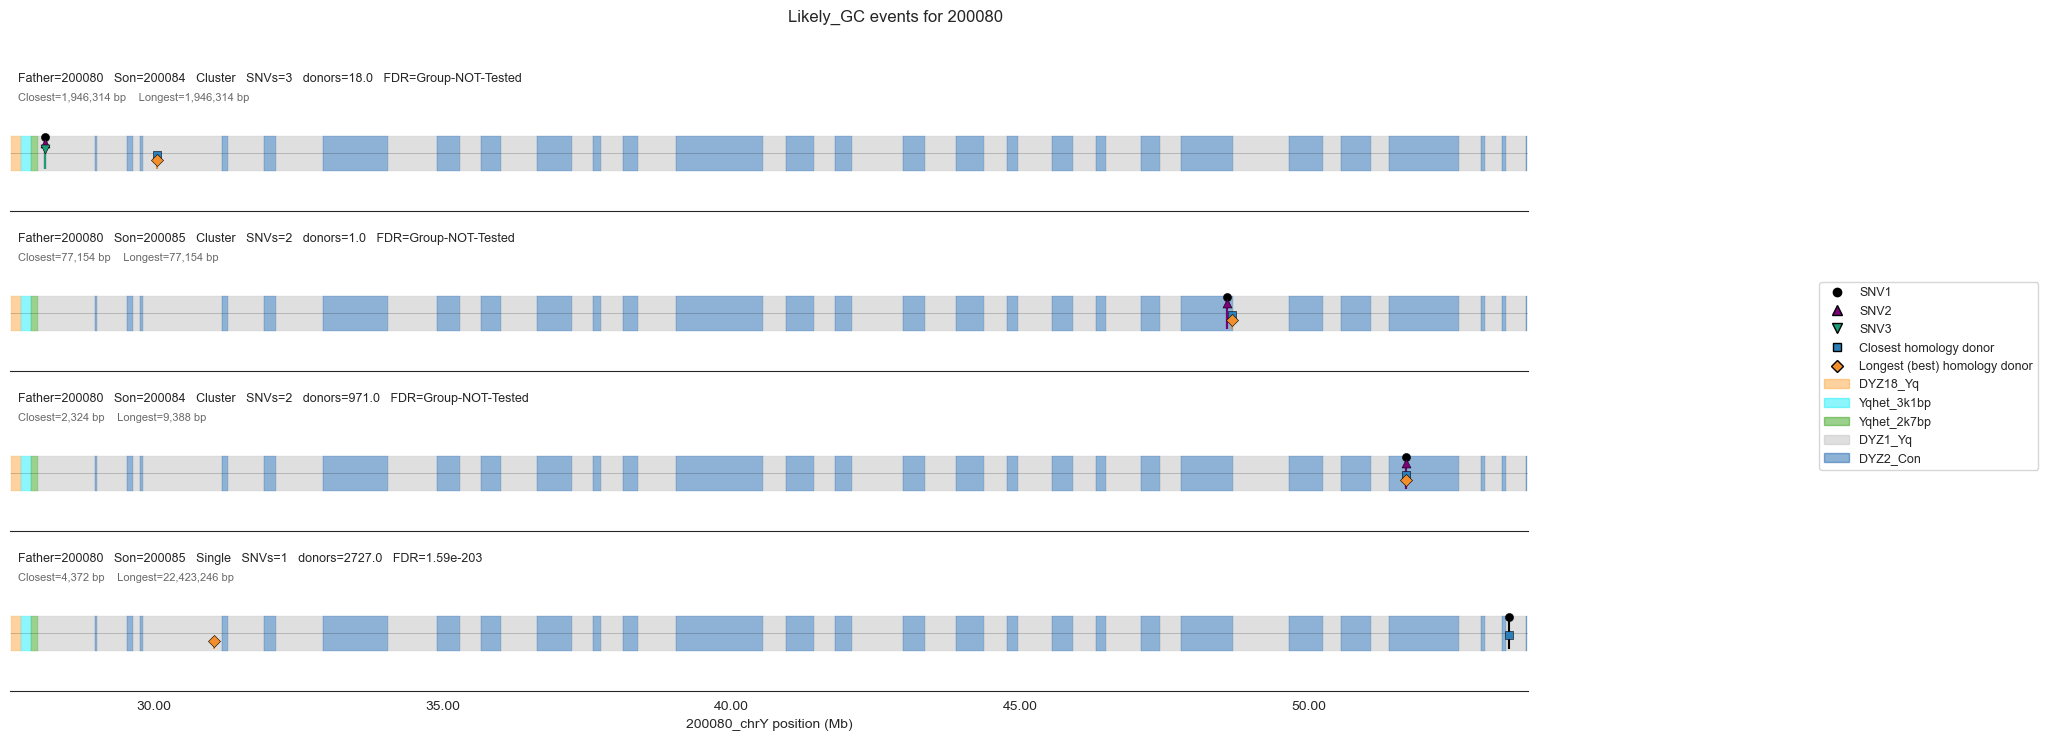

In [40]:
arch = prepare_architecture_df(
    Father200080,
    contig_col="0",
    label_col="1",
    strand_col="2",
    start_col="3",
    end_col="4",
)

outputs = plot_likely_gc_donors(
    Father200080DF,
    out_dir="LikelyGCPlots",
    architecture_df=arch,
    show=True,
)

/var/folders/xz/zh_wvx4s1xq705hg124_s53jqzy1bl/T/ipykernel_7034/1570751883.py:46: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  s = s.replace({"NONE": np.nan, "nan": np.nan, "NaN": np.nan, "": np.nan})


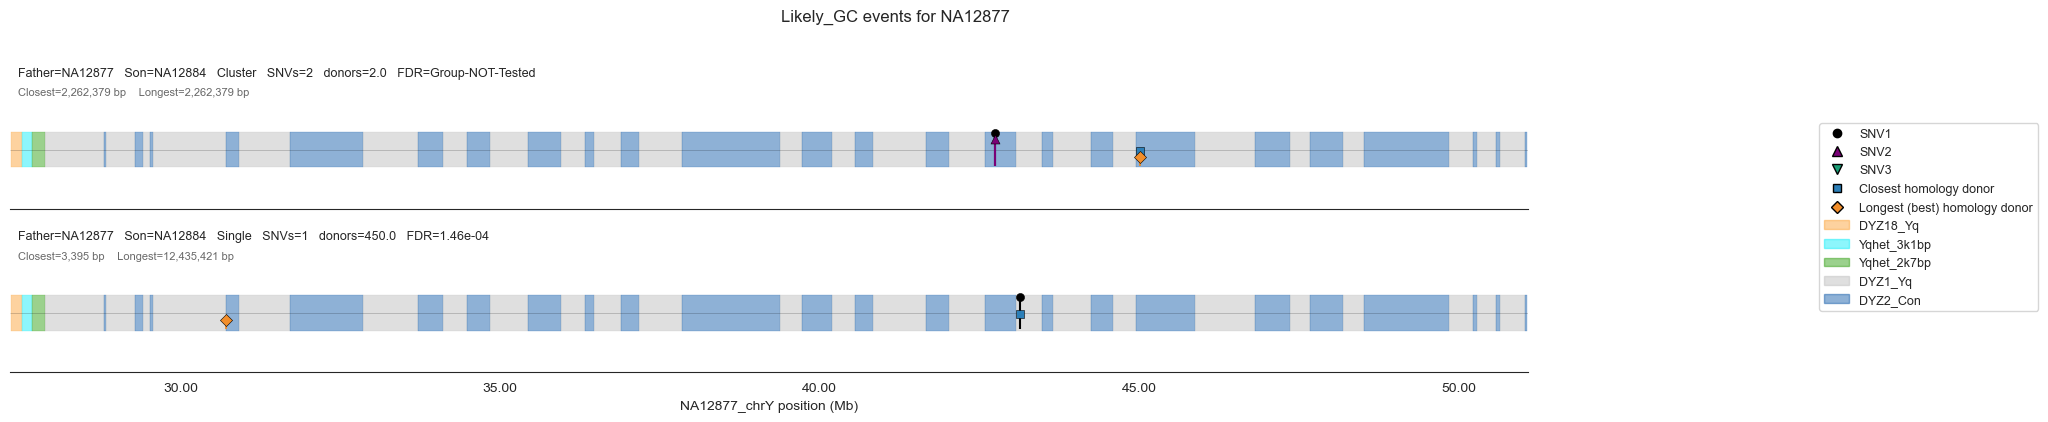

In [41]:
arch = prepare_architecture_df(
    FatherNA12877,
    contig_col="0",
    label_col="1",
    strand_col="2",
    start_col="3",
    end_col="4",
)

outputs = plot_likely_gc_donors(
    FatherNA12877DF,
    out_dir="LikelyGCPlots",
    architecture_df=arch,
    show=True,
)

In [42]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.colors as mcolors
import colorsys

def soften_color(color, saturation_scale=0.55, lightness_scale=1.15):
    """
    Make a color less saturated and slightly lighter.
    """
    r, g, b = mcolors.to_rgb(color)
    h, l, s = colorsys.rgb_to_hls(r, g, b)

    s = max(0, min(1, s * saturation_scale))
    l = max(0, min(1, l * lightness_scale))

    r2, g2, b2 = colorsys.hls_to_rgb(h, l, s)
    return (r2, g2, b2)

def plot_closest_donor_density_overlay(
    df,
    classification=None,
    log10_x=False,
    outpath=None,
    dpi=300,
    add_likely_gc_rug=True
):
    plot_df = df.copy()
    plot_df["ClosestDonorDistance"] = pd.to_numeric(
        plot_df["ClosestDonorDistance"], errors="coerce"
    )
    plot_df = plot_df.dropna(subset=["FatherID", "ClosestDonorDistance"]).copy()
    plot_df = plot_df[plot_df["ClosestDonorDistance"] > 0].copy()

    if classification is not None:
        plot_df = plot_df[plot_df["Classification"] == classification].copy()

    if plot_df.empty:
        print("No rows left after filtering.")
        return

    if log10_x:
        plot_df["xplot"] = np.log10(plot_df["ClosestDonorDistance"])
        xlabel = "log10 closest donor distance (bp)"
        clip_min = plot_df["xplot"].min()
    else:
        plot_df["xplot"] = plot_df["ClosestDonorDistance"]
        xlabel = "Closest donor distance (bp)"
        clip_min = 0

    plot_df["FatherID"] = plot_df["FatherID"].astype(str)

    father_counts = (
        plot_df.groupby("FatherID")
        .size()
        .sort_index()
        .to_dict()
    )
    father_order = sorted(plot_df["FatherID"].unique())

    palette_list = [
        "#1F77B4", "#D62728", "#2CA02C", "#9467BD", "#FF7F0E",
        "#17BECF", "#E377C2", "#8C564B"
    ]
    palette = {
        father: palette_list[i % len(palette_list)]
        for i, father in enumerate(father_order)
    }

    rug_palette = {
        father: soften_color(palette[father], saturation_scale=0.5, lightness_scale=1.2)
        for father in father_order
    }

    sns.set_style("whitegrid")
    plt.figure(figsize=(8, 5))

    ax = sns.kdeplot(
        data=plot_df,
        x="xplot",
        hue="FatherID",
        hue_order=father_order,
        palette=palette,
        fill=False,
        common_norm=False,
        cut=0,
        clip=(clip_min, None),
        bw_adjust=0.5,
        linewidth=2
    )

    if add_likely_gc_rug and "Classification" in plot_df.columns:
        rug_df = plot_df[plot_df["Classification"] == "Likely_GC"].copy()

        if not rug_df.empty:
            for father in father_order:
                sub_rug = rug_df[rug_df["FatherID"] == father]
                if not sub_rug.empty:
                    sns.rugplot(
                        data=sub_rug,
                        x="xplot",
                        ax=ax,
                        color=rug_palette[father],
                        height=0.08,
                        linewidth=1.4,
                        alpha=1.0,
                        clip_on=False
                    )

    plt.xlabel(xlabel)
    plt.ylabel("Density")

    if not log10_x:
        plt.xlim(left=0)

    leg = ax.get_legend()
    if leg is not None:
        for text in leg.texts:
            father = text.get_text()
            if father in father_counts:
                text.set_text(f"{father} (n={father_counts[father]})")
        leg.set_title("FatherID")

    plt.tight_layout()

    if outpath is not None:
        plt.savefig(outpath, dpi=dpi, bbox_inches="tight")

    plt.show()

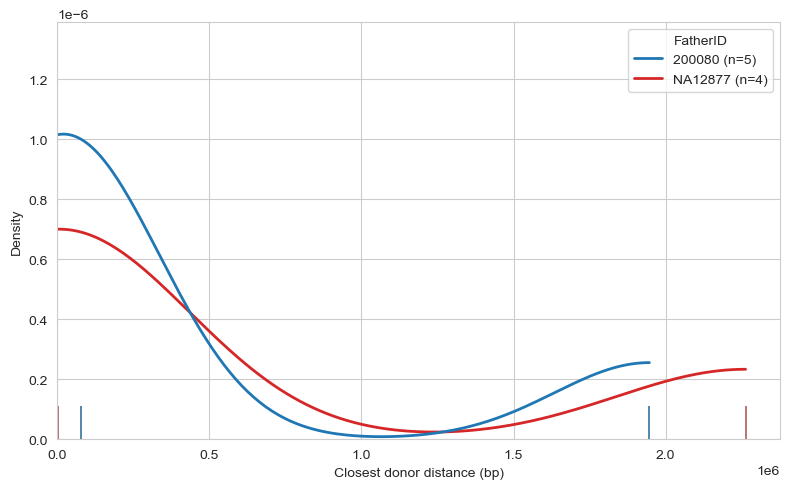

In [43]:
plot_closest_donor_density_overlay(
    df2,
    classification=None,
    log10_x=False,
    #outpath="/closest_donor_density.pdf"
)

In [46]:
df3 =df2[df2['Classification']=='Likely_GC'].copy()

In [53]:
lengths=[]
for x in df3['ClosestDonor']:
    coords = x.split(":")[1].split("(")[0]
    lengths.append(int(coords.split("-")[1])-int(coords.split("-")[0]))

print(np.min(lengths))
print(np.median(lengths))
print(np.mean(lengths))
print(np.max(lengths))


217
349.0
426.0
681


In [55]:
df2

,FatherID,SonID,Father_contig,Classification,GroupSize,SNV1,SNV2,SNV3,TotalMatchDonors,ClosestDonor,ClosestDonorDistance,LongestDonor,LongestDonorDistance,gc_p_fdr
0,200080,200085,200080_chrY,GC_candidate,Single,52383887,NONE,NONE,481.0,200080_chrY:52381299-52382230(+),1657,200080_chrY:52363990-52365963(+),17924,0.9998739977988508
1,200080,200085,200080_chrY,Likely_GC,Single,53464071,NONE,NONE,2727.0,200080_chrY:53468443-53468753(-),4372,200080_chrY:31040119-31040825(-),22423246,1.5947511921756108e-203
2,NA12877,NA12882,NA12877_chrY,GC_candidate,Single,38670479,NONE,NONE,17.0,NA12877_chrY:38651838-38653799(+),16680,NA12877_chrY:38151351-38157012(+),513467,0.8342478796839714
3,NA12877,NA12884,NA12877_chrY,Likely_GC,Single,43141197,NONE,NONE,450.0,NA12877_chrY:43144592-43144934(+),3395,NA12877_chrY:30705140-30705776(+),12435421,0.000145674655299
4,NA12877,NA12884,NA12877_chrY,GC_candidate,Single,43717541,NONE,NONE,9.0,NA12877_chrY:43719297-43722072(+),1756,NA12877_chrY:43719297-43722072(+),1756,0.2083333333333333
5,200080,200084,200080_chrY,Likely_GC,Cluster,28112065,28112220,28112490,18.0,200080_chrY:30058534-30059215(+),1946314,200080_chrY:30058534-30059215(+),1946314,Group-NOT-Tested
6,200080,200085,200080_chrY,Likely_GC,Cluster,48581912,48581917,NONE,1.0,200080_chrY:48659071-48659427(+),77154,200080_chrY:48659071-48659427(+),77154,Group-NOT-Tested
7,200080,200084,200080_chrY,Likely_GC,Cluster,51684849,51684856,NONE,971.0,200080_chrY:51682308-51682525(+),2324,200080_chrY:51675048-51675461(+),9388,Group-NOT-Tested
8,NA12877,NA12884,NA12877_chrY,Likely_GC,Cluster,42752374,42752508,NONE,2.0,NA12877_chrY:45014887-45015537(+),2262379,NA12877_chrY:45014887-45015537(+),2262379,Group-NOT-Tested
